1. Fashion MNIST contains grayscale images of clothes like shirts, shoes, bags, etc.
Dataset size:
60,000 training images
10,000 testing images
Each image size = 28 × 28 pixels. has 10 classes

2. 'Sequential' is a model type in TensorFlow / Keras where layers are added one after another in order.

3. CNN = Used mainly for images.
“convolutional” = mathematical operation = A small filter/kernel slides over the image and detects patterns.

1) Image is given to CNN.
2) A small matrix slides over image to detect patterns. edges, lines,textures
3) Pooling Layer: Reduces feature map size. Keeps strongest features while reducing computation.
4) this layers are repeated. to learn edges and shapes
5) Flatten Layer: Converts 2D feature maps into 1D vector.
6) Fully Connected (Dense) Layer:-
Normal neural network layer.
Combines all learned features and makes decision.
7) Output Layer (Softmax):-
Gives probability for each class.

why 2d?
Conv2D is called 2D because the filter moves in 2 dimensions over the image: height and width

add() is a method used to put layers inside a Sequential model.

Dropout is a layer used to prevent overfitting in neural networks.
During training, it randomly turns off some neurons temporarily.

A batch = small group of training samples processed together.
Eg: 300 images and 30 batch size = 10 batches

(batch_size, height, width, channels)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
from tensorflow.keras.datasets import fashion_mnist

(trainX, trainY), (testX, testY) = fashion_mnist.load_data()

print(trainX.shape, testX.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [11]:
# We are changing the shape of the image data so CNN can understand it.
# Original MNIST/Fashion-MNIST shape:
# (60000, 28, 28)
# But CNN expects:
# (batch_size, height, width, channels)

trainX = trainX.reshape((60000, 28, 28, 1))
testX = testX.reshape((10000, 28, 28, 1))


In [13]:
# Min-Max normalization: scaling values from: 0–255 → 0–1

trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0


In [5]:
# converts class labels into one-hot encoded vectors.
# Before: 3
# After: [0,0,0,1,0,0,0,0,0,0]
# from tensorflow.keras.utils import to_categorical
# Because output layer often uses:
# softmax
# categorical_crossentropy
# which expect one-hot encoded labels.

trainY = to_categorical(trainY)
testY = to_categorical(testY)


In [6]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential()

# Convolution Block 1
# 32 filters of size 3×3
# extracts features like edges and textures
# input image size is 28×28 grayscale (1 channel)
# ReLU adds nonlinearity
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Convolution Block 2
# 64 filters
# learns more complex patterns
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
# Converts 2D feature maps into 1D vector for Dense layers.
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#An optimizer is the algorithm that updates the neural network’s weights during training to reduce error/loss.

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
history = model.fit(
    trainX, trainY,
    epochs=10,
    batch_size=32,
    validation_data=(testX, testY)
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.7919 - loss: 0.5744 - val_accuracy: 0.8618 - val_loss: 0.3817
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.8614 - loss: 0.3852 - val_accuracy: 0.8846 - val_loss: 0.3203
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8769 - loss: 0.3373 - val_accuracy: 0.8899 - val_loss: 0.2954
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.8918 - loss: 0.2999 - val_accuracy: 0.8962 - val_loss: 0.2837
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8978 - loss: 0.2789 - val_accuracy: 0.9016 - val_loss: 0.2720
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9028 - loss: 0.2607 - val_accuracy: 0.8992 - val_loss: 0.2685
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 34ms/step - accuracy: 0.9093 - loss: 0.2468 - val_accuracy: 0.9081 - val_loss: 0.2563
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.9126 -

In [9]:
loss, accuracy = model.evaluate(testX, testY)
print("Test Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9060 - loss: 0.2594
Test Accuracy: 0.906000018119812


# Prediction On Data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted class index : 9
Predicted label       : Ankle boot
Confidence            : 100.00%


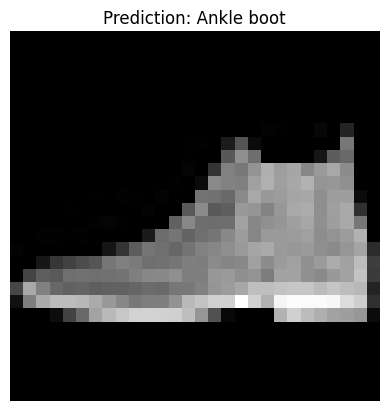

In [10]:
# Pick a single image from test set
sample_index = 0
sample_image = testX[sample_index]          # shape: (28, 28, 1)

# Model expects a batch → add batch dimension
sample_input = np.expand_dims(sample_image, axis=0)   # shape: (1, 28, 28, 1)

# Predict
# The model predicts probabilities for all classes.
# [[0.01, 0.02, 0.80, 0.03, 0.01, 0.04, 0.02, 0.03, 0.02, 0.02]]
predictions = model.predict(sample_input)

# argmax() finds index of highest probability.
predicted_class = np.argmax(predictions)

# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Predicted class index : {predicted_class}")
print(f"Predicted label       : {class_names[predicted_class]}")
print(f"Confidence            : {predictions[0][predicted_class]*100:.2f}%")

# Visualize the image
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis('off')
plt.show()